In [ ]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable
import torch.nn.functional as F
import numpy as np
import time
import math
from PIL import Image
import matplotlib.pyplot as plt
from models import *
from dataloader import KITTILoader as DA
from dataloader import preprocess

In [ ]:
# TRAINING LOOP FOR 5 EPOCHS
start_full_time = time.time()

for epoch in range(start_epoch, epochs + 1):
    total_train_loss = 0
    total_test_loss = 0

    ## Training ##
    for batch_idx, (imgL_crop, imgR_crop, disp_crop_L) in enumerate(TrainImgLoader):
        start_time = time.time()
        loss = train(imgL_crop, imgR_crop, disp_crop_L)
        print(f'Epoch {epoch}, Iter {batch_idx} training loss = {loss:.3f}, time = {(time.time() - start_time):.2f}')
        total_train_loss += loss
    print(f'epoch {epoch} total training loss = {total_train_loss / len(TrainImgLoader):.3f}')

    ## Validation ##
    for batch_idx, (imgL, imgR, disp_L) in enumerate(TestImgLoader):
        test_loss = test(imgL, imgR, disp_L)
        print(f'Iter {batch_idx} validation loss = {test_loss:.3f}')
        total_test_loss += test_loss
    
    avg_test_loss = total_test_loss / len(TestImgLoader)
    print(f'epoch {epoch} total validation loss = {avg_test_loss:.3f}')

    # Save best checkpoint
    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        savefilename = os.path.join(savemodel, 'best_checkpoint5.tar')
        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(), 
            'train_loss': total_train_loss / len(TrainImgLoader),
            'test_loss': avg_test_loss,
        }, savefilename)
        print(f"Saved best model at epoch {epoch} with validation loss {avg_test_loss:.3f}")

print('Full training time = %.2f HR' % ((time.time() - start_full_time) / 3600))

/home/prath_linux/anaconda3/envs/cnn/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


Epoch 4, Iter 0 training loss = 23.675, time = 29.14
Epoch 4, Iter 1 training loss = 11.063, time = 24.82
Epoch 4, Iter 2 training loss = 13.306, time = 23.45
Epoch 4, Iter 3 training loss = 21.481, time = 25.05
Epoch 4, Iter 4 training loss = 15.932, time = 25.20
Epoch 4, Iter 5 training loss = 14.322, time = 24.90
Epoch 4, Iter 6 training loss = 18.880, time = 23.38
Epoch 4, Iter 7 training loss = 19.900, time = 24.91
Epoch 4, Iter 8 training loss = 14.548, time = 24.95
Epoch 4, Iter 9 training loss = 16.239, time = 25.01
Epoch 4, Iter 10 training loss = 13.160, time = 23.45
Epoch 4, Iter 11 training loss = 17.243, time = 25.01
Epoch 4, Iter 12 training loss = 14.791, time = 24.93
Epoch 4, Iter 13 training loss = 12.808, time = 23.33
Epoch 4, Iter 14 training loss = 15.751, time = 23.43
Epoch 4, Iter 15 training loss = 12.379, time = 23.72
Epoch 4, Iter 16 training loss = 11.304, time = 21.84
Epoch 4, Iter 17 training loss = 11.870, time = 23.51
Epoch 4, Iter 18 training loss = 10.80

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
/tmp/ipykernel_325359/3835967028.py:58: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



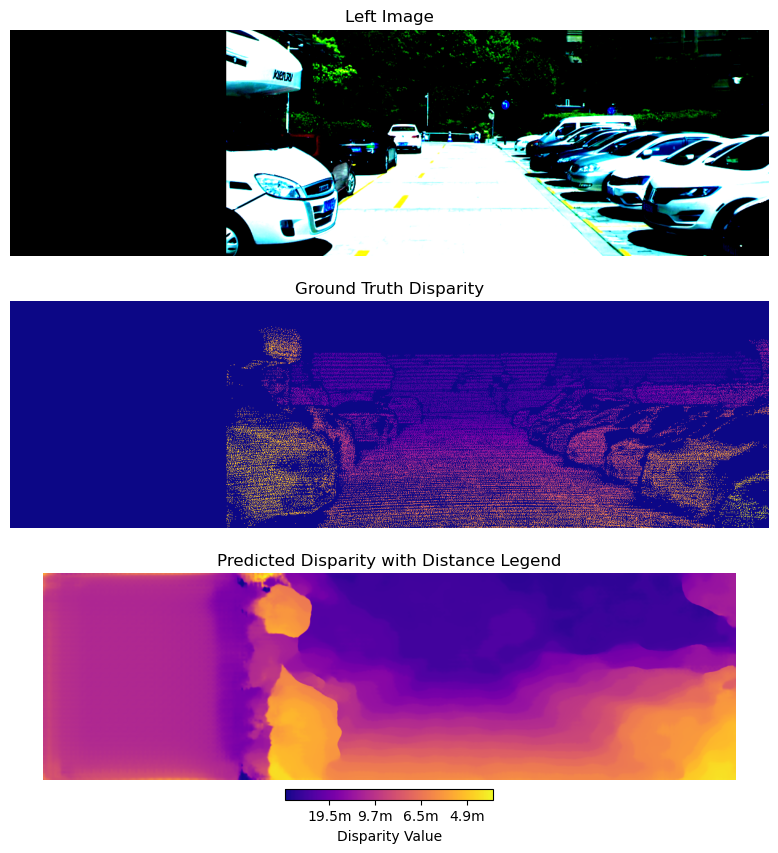

In [ ]:
# TESTING FOR 5 EPOCHS
FOCAL_LENGTH = 721 
BASELINE = 0.54 

if model_name == 'stackhourglass':
    model = stackhourglass(maxdisp)
else:
    model = basic(maxdisp)
    
if cuda_available:
    model = nn.DataParallel(model)
    model.cuda()
    
state_dict = torch.load('./best_checkpoint5.tar')
model.load_state_dict(state_dict['state_dict'])

imgL, imgR, disp_L = next(iter(TestImgLoader))
rand_idx = random.randint(0, imgL.size(0) - 1)

plot_disparity_static(
    imgL[rand_idx].unsqueeze(0), 
    imgR[rand_idx].unsqueeze(0), 
    disp_L[rand_idx].unsqueeze(0), 
    model,
    focal_length=FOCAL_LENGTH,
    baseline=BASELINE
)